In [7]:
import numpy as np
import matplotlib.pyplot as plt

from piwavelet.plotting.wavelet import (
    plot_wavelet
)
from piwavelet.plotting.wavelet_power_spectrum import (
    plot_wavelet_power_spectrum
)

from piwavelet.transforms.cwt import cwt

from piwavelet.diagnostics import compute_wavelet_diagnostics


import matplotlib.pyplot as plt
import numpy as np

from piwavelet.features.scalogram import (
    wavelet_scalogram,
)

from piwavelet.features.image import (
    resize_scalogram,
    to_uint8,
)

In [8]:
# ----------------------------------------------------------------------
# synthetic signal
# ----------------------------------------------------------------------

dt = 0.25

time = np.arange(0, 512) * dt

signal = (
    np.sin(2 * np.pi * time / 16)
    + 0.5 * np.sin(2 * np.pi * time / 64)
)

signal += 0.2 * np.random.randn(time.size)

normalized_signal = (
    signal - signal.mean()
) / signal.std()

In [9]:
# ----------------------------------------------------------------------
# compute cwt
# ----------------------------------------------------------------------

result = cwt(
    signal=normalized_signal,
    dt=dt,
    time=time,
)



In [10]:
diagnostics = compute_wavelet_diagnostics(
    result,
    signal=signal,
    normalized_signal=normalized_signal,
)

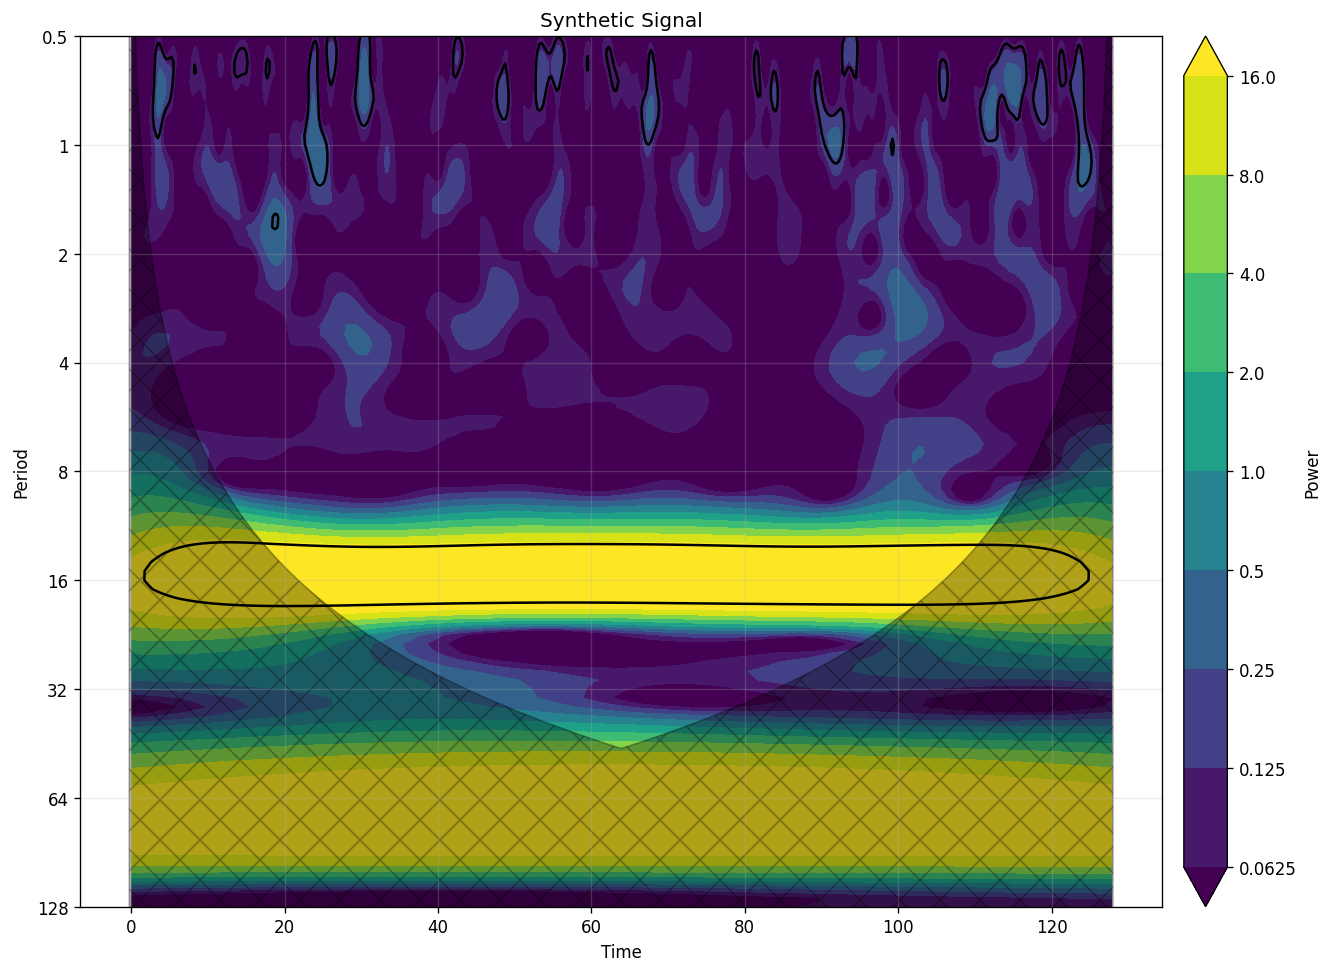

In [11]:
fig, ax = plot_wavelet_power_spectrum(
    diagnostics,
    title="Synthetic Signal",
)

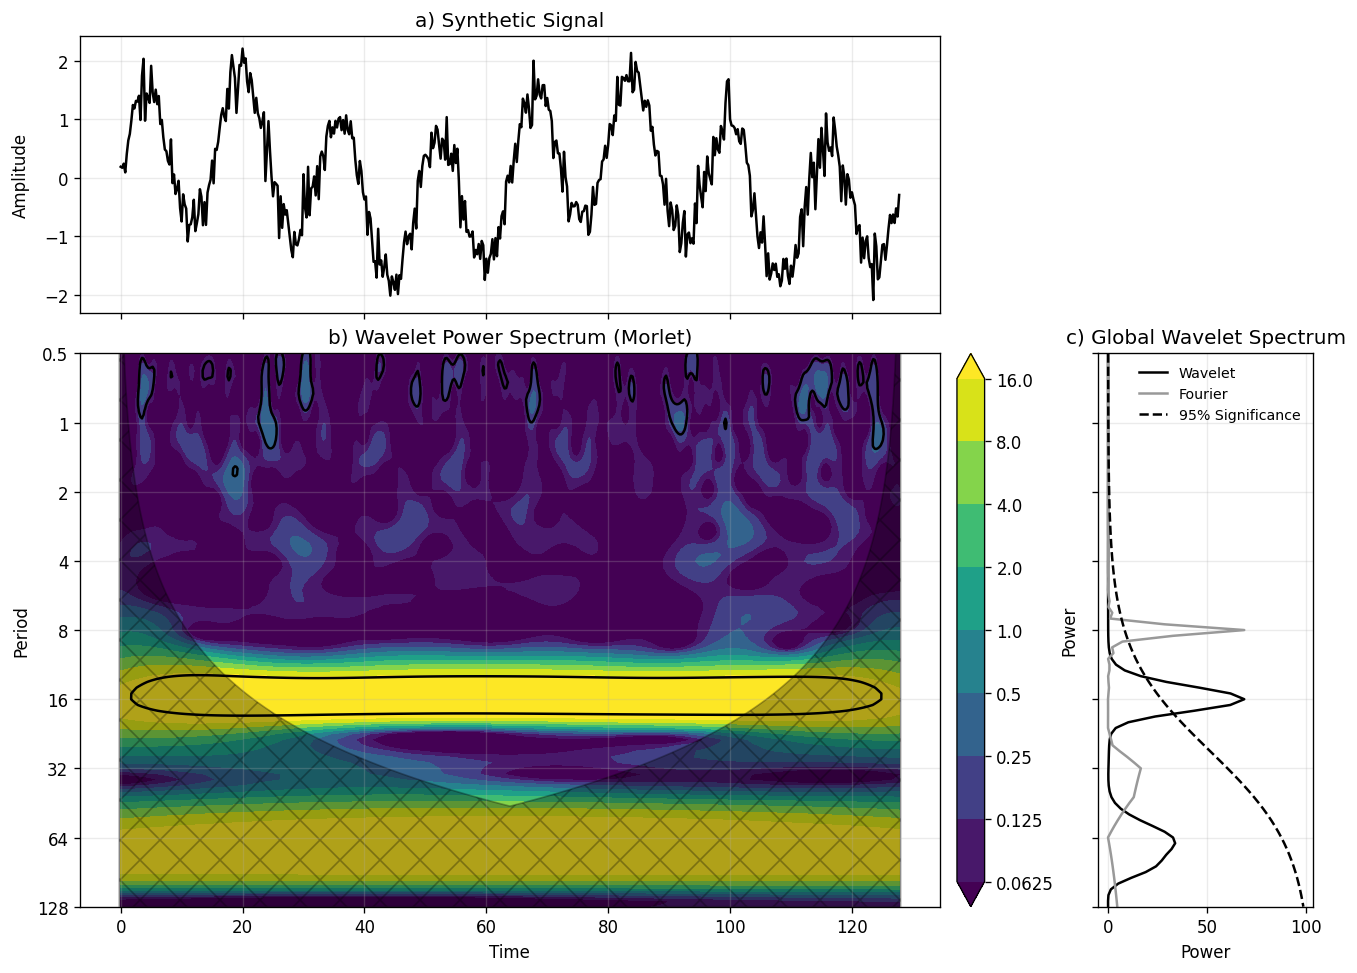

In [12]:
# ----------------------------------------------------------------------
# plot
# ----------------------------------------------------------------------

fig = plot_wavelet(
    diagnostics,
    title="Synthetic Signal",
    signal_label="Amplitude",
    show_scale_average=False,
)

plt.show()

scalogram shape: (97, 512)
cnn image shape: (224, 224)
uint8


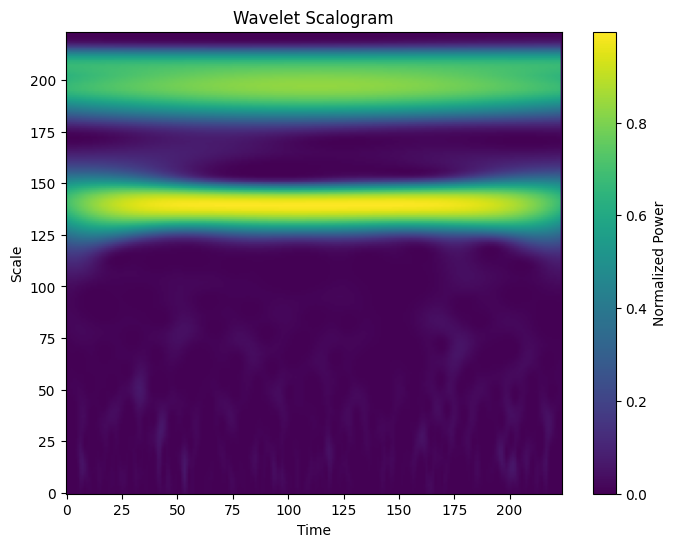

In [13]:
# ----------------------------------------------------------------------
# compute wavelet scalogram
# ----------------------------------------------------------------------

scalogram = wavelet_scalogram(
    signal,
    dt=dt,
    output="power",
    log_transform=True,
    normalization="minmax",
)

print(
    "scalogram shape:",
    scalogram.shape,
)

# ----------------------------------------------------------------------
# resize for CNN input
# ----------------------------------------------------------------------

image = resize_scalogram(
    scalogram,
    size=(224, 224),
)

print(
    "cnn image shape:",
    image.shape,
)

# ----------------------------------------------------------------------
# convert to uint8 image
# ----------------------------------------------------------------------

image_uint8 = to_uint8(
    image
)

print(
    image_uint8.dtype
)

# ----------------------------------------------------------------------
# visualize
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

im = ax.imshow(
    image,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)

ax.set_title(
    "Wavelet Scalogram"
)

ax.set_xlabel(
    "Time"
)

ax.set_ylabel(
    "Scale"
)

fig.colorbar(
    im,
    ax=ax,
    label="Normalized Power",
)

plt.show()